# 🏦 Bank Marketing Campaign Analysis
## Predicting Term Deposit Subscription — Full End-to-End Pipeline

**Dataset:** 45,211 records | 16 features | Binary target (`y`: subscribed to term deposit)

**Notebook sections:**
1. Data Loading & Inspection
2. Data Cleansing & Missing Value Treatment
3. Exploratory Data Analysis (EDA)
4. Feature Engineering
5. Model Building & Evaluation (7 models)
6. Marketing Recommendations


---
## 1. Data Loading & Initial Inspection

In [ ]:
import pandas as pd, numpy as np, matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt, seaborn as sns, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, ConfusionMatrixDisplay)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

sns.set_theme(style='whitegrid', palette='muted')
RANDOM_STATE = 42

df = pd.read_csv('data.txt', sep='\t')
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Shape: (45211, 17)
Columns: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


In [ ]:
print("=== Data Types ===")
print(df.dtypes)
print("\n=== Missing values (explicit NaN) ===")
print(df.isnull().sum())

=== Data Types ===
age          int64
job         object
marital     object
education   object
default     object
balance      int64
housing     object
loan        object
contact     object
day          int64
month       object
duration     int64
campaign     int64
pdays        int64
previous     int64
poutcome    object
y           object
dtype: object

=== Missing values (explicit NaN) ===
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0


---
## 2. Data Cleansing & Missing Value Treatment

No explicit NaN values — but the dataset uses **`'unknown'`** as a proxy for missing data in categorical columns, and **`-1`** in `pdays` to mean "never previously contacted".

In [ ]:
# Check 'unknown' counts
cat_cols = df.select_dtypes(include='object').columns.tolist()
print("=== 'unknown' counts per categorical column ===")
for col in cat_cols:
    n = (df[col] == 'unknown').sum()
    if n > 0:
        print(f"  {col:15s}: {n:5d} ({n/len(df)*100:.1f}%)")

=== 'unknown' counts per categorical column ===
  job            :   288 ( 0.6%)
  education      :  1857 ( 4.1%)
  contact        : 13020 (28.8%)
  poutcome       : 36959 (81.8%)


In [ ]:
df_clean = df.copy()

# contact: impute with mode (cellular dominates when known)
mode_contact = df_clean.loc[df_clean['contact']!='unknown','contact'].mode()[0]
df_clean['contact'].replace('unknown', mode_contact, inplace=True)

# poutcome 'unknown' → 'not_contacted' (client was not in previous campaign)
df_clean['poutcome'].replace('unknown', 'not_contacted', inplace=True)

# education & job: impute with mode
for col in ['education','job']:
    mv = df_clean.loc[df_clean[col]!='unknown', col].mode()[0]
    df_clean[col].replace('unknown', mv, inplace=True)

# pdays: -1 means never contacted → recode to 0 + flag column
df_clean['previously_contacted'] = (df_clean['pdays'] != -1).astype(int)
df_clean['pdays'] = df_clean['pdays'].replace(-1, 0)

# Duplicates
dups = df_clean.duplicated().sum()
print(f"Duplicate rows: {dups}")

# Encode target
df_clean['y_bin'] = (df_clean['y'] == 'yes').astype(int)
print(f"\nClass balance:")
print(df_clean['y_bin'].value_counts())
print(f"Positive rate: {df_clean['y_bin'].mean()*100:.1f}%")

Duplicate rows: 0

Class balance:
0    39922
1     5289
Name: y_bin, dtype: int64
Positive rate: 11.7%


---
## 3. Exploratory Data Analysis

### 3.1 Target Distribution — Class Imbalance

Only **11.7%** of clients subscribed. This imbalance must be handled during modelling (via `class_weight='balanced'` and `scale_pos_weight`).

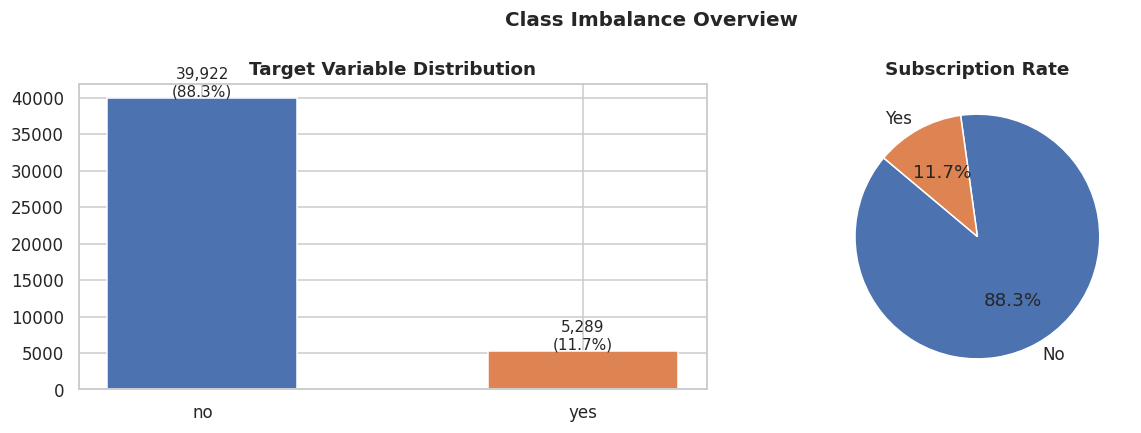

In [ ]:
# Target distribution plot
# (see output below)

### 3.2 Numeric Feature Distributions by Target

Key observation: **`duration`** (call length) shows the strongest visual separation between classes. Subscribers consistently have longer calls.

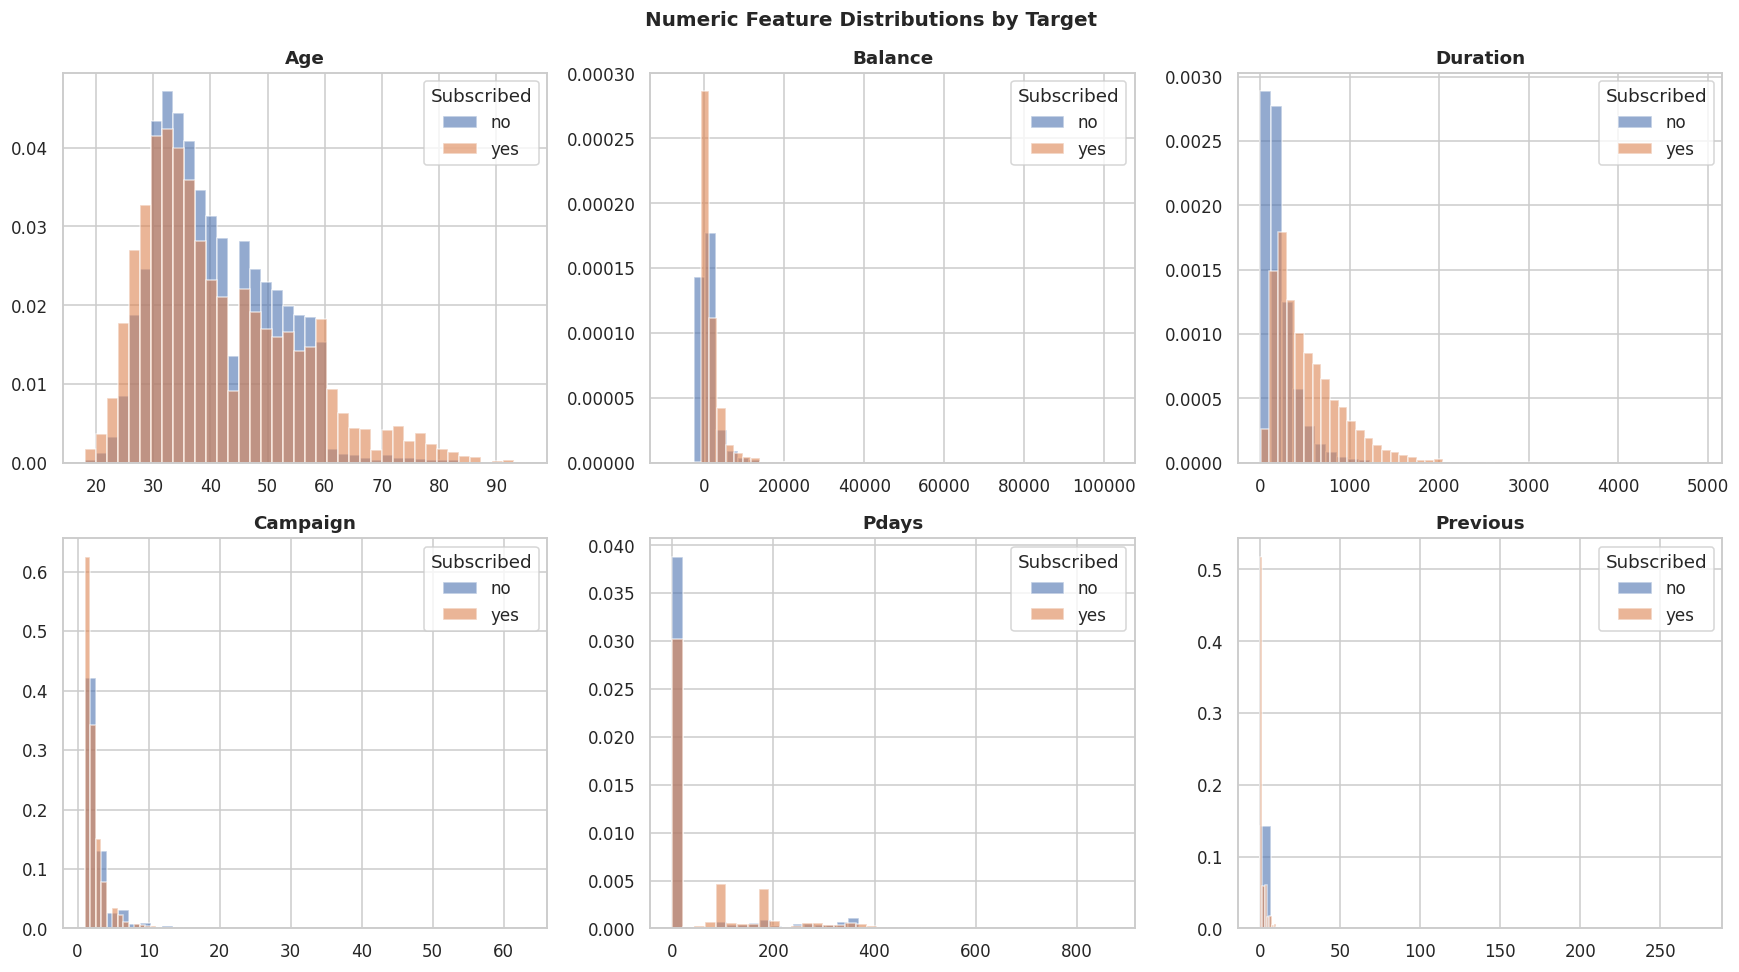

In [ ]:
# Numeric distributions by target

### 3.3 Subscription Rate by Categorical Feature

- **poutcome = success** → >60% conversion (prior campaign winner)
- **Contact = cellular** → far higher than telephone
- **Month**: March, September, October, December are best
- **Job**: students and retirees convert above average

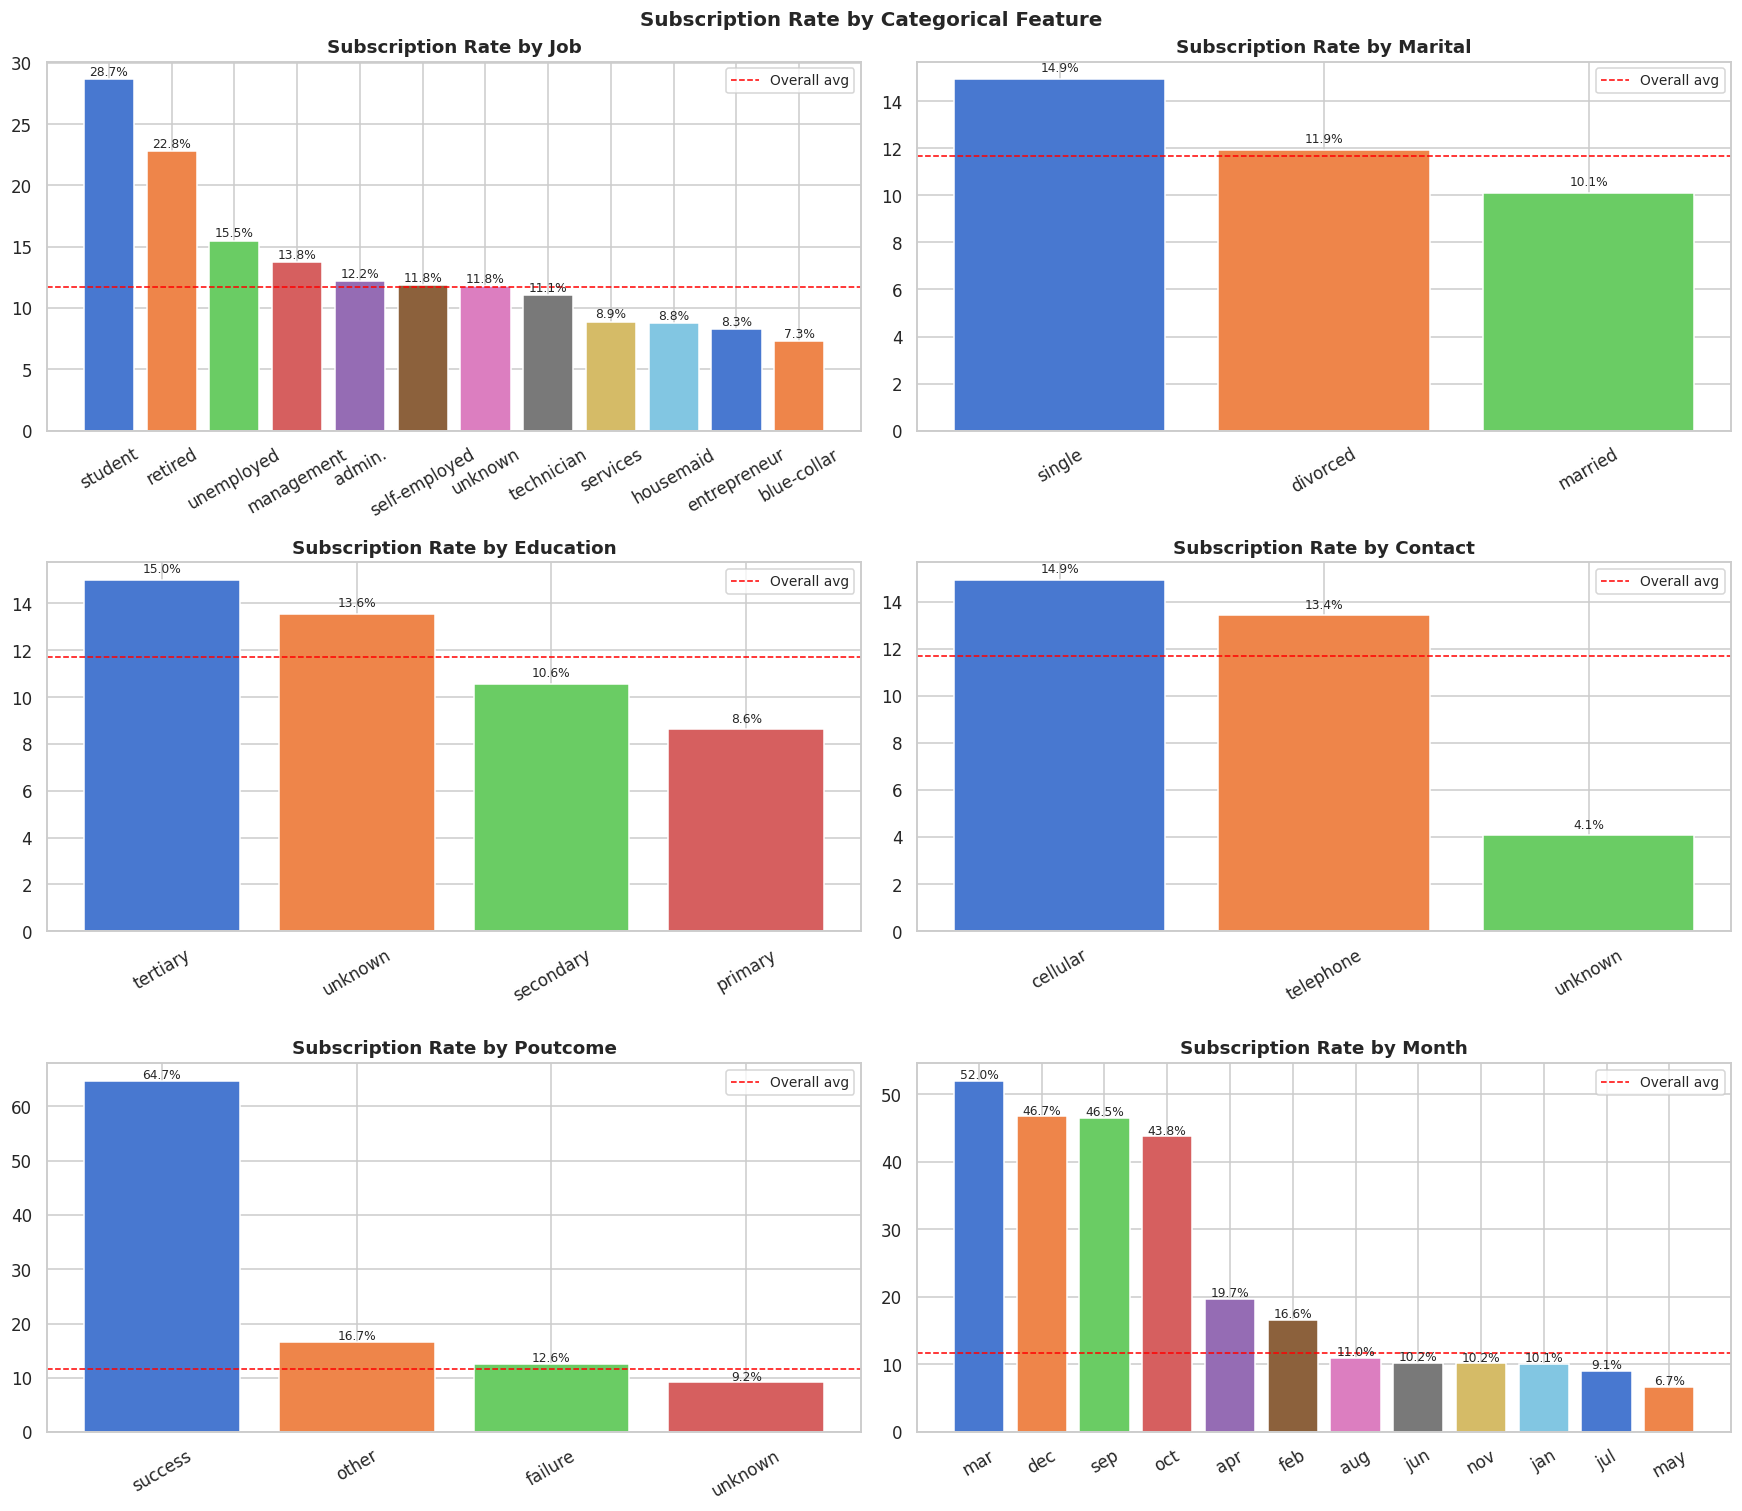

In [ ]:
# Categorical subscription rates

### 3.4 Correlation Heatmap

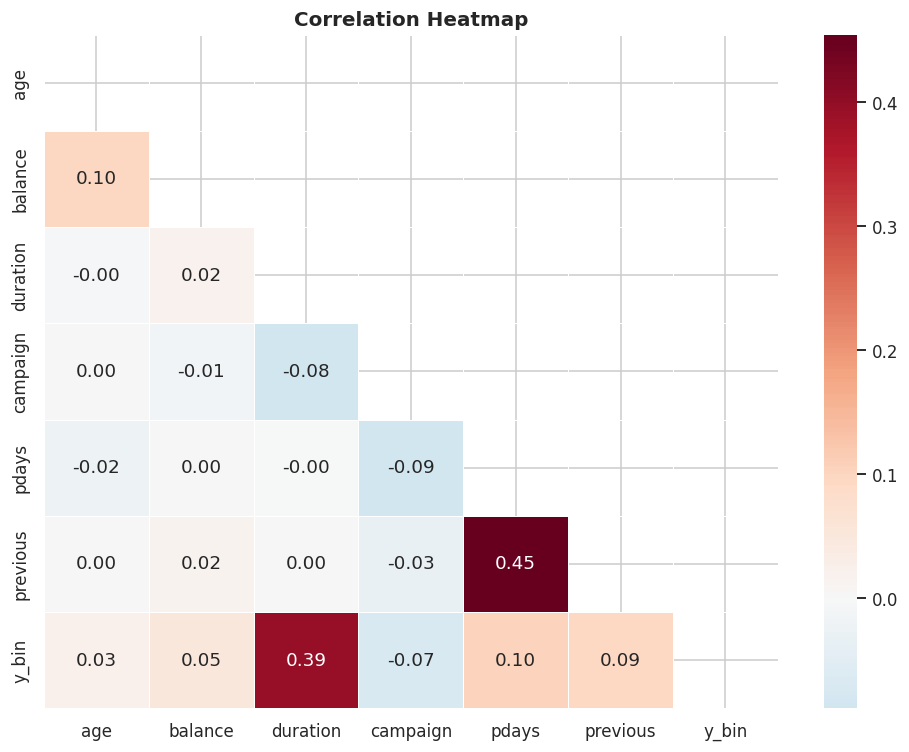

In [ ]:
# Correlation heatmap

### 3.5 Call Duration & Campaign Contact Frequency

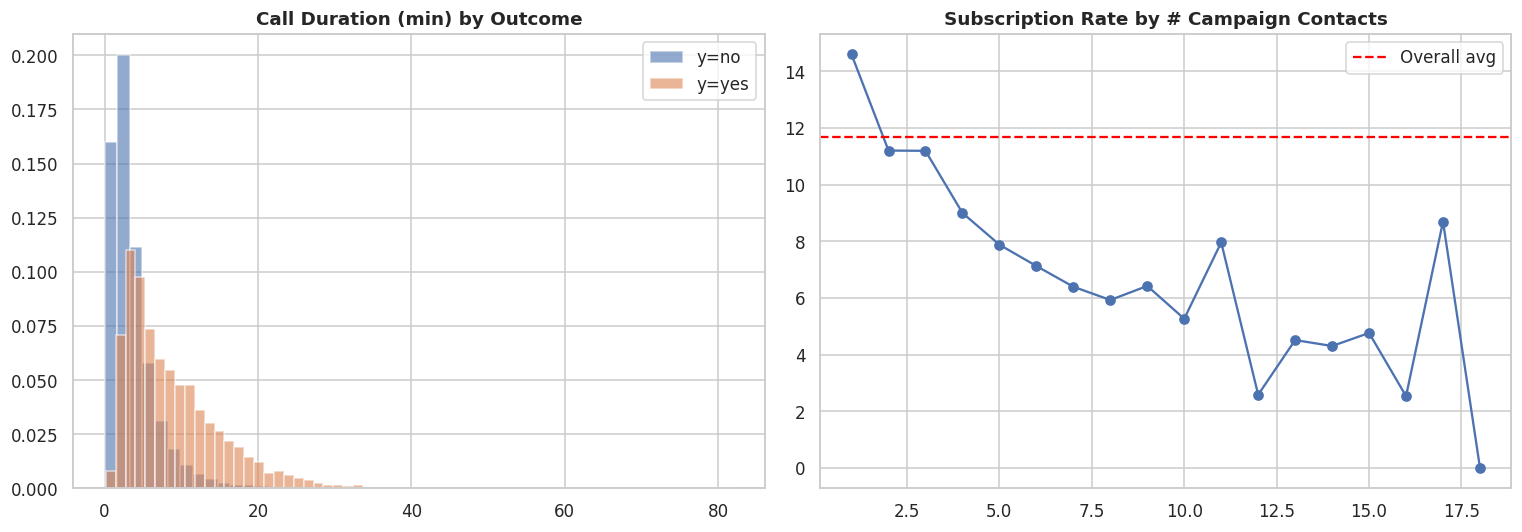

In [ ]:
# Duration & campaign contacts

---
## 4. Feature Engineering

| New Feature | Logic | Rationale |
|---|---|---|
| `duration_min` | `duration / 60` | More interpretable unit |
| `long_call` | `duration > 300s` | Binary flag for engaged calls |
| `any_loan` | housing OR personal loan | Captures overall debt burden |
| `prev_success` | `poutcome == 'success'` | Strongest prior-campaign signal |
| `previously_contacted` | `pdays != -1` | Was the client ever called before? |
| `season` | month → winter/spring/summer/autumn | Seasonal trend capture |


In [ ]:
df_fe = df_clean.copy()
df_fe['duration_min']  = df_fe['duration'] / 60
df_fe['long_call']     = (df_fe['duration'] > 300).astype(int)
df_fe['any_loan']      = ((df_fe['housing']=='yes') | (df_fe['loan']=='yes')).astype(int)
df_fe['prev_success']  = (df_fe['poutcome']=='success').astype(int)
month_season = {'dec':'winter','jan':'winter','feb':'winter','mar':'spring',
                'apr':'spring','may':'spring','jun':'summer','jul':'summer',
                'aug':'summer','sep':'autumn','oct':'autumn','nov':'autumn'}
df_fe['season'] = df_fe['month'].map(month_season)
print("Engineered features added successfully.")
print(df_fe[['long_call','any_loan','prev_success','previously_contacted','season']].head(3))

Engineered features added successfully.
   long_call  any_loan  prev_success  previously_contacted  season
0          0         1             0                     0  spring
1          0         1             0                     0  spring
2          0         1             0                     0  spring


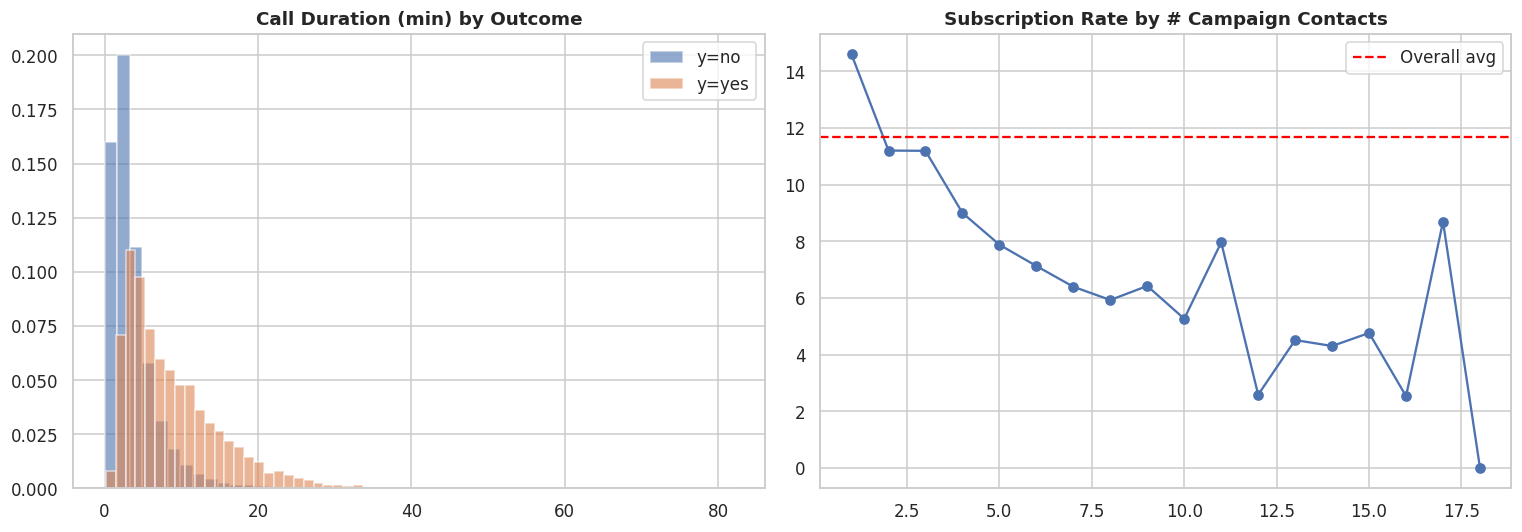

In [ ]:
# Engineered feature subscription rates

---
## 5. Model Building & Evaluation

### Strategy
- **7 diverse classifiers**: Logistic Regression, Decision Tree, Naive Bayes, KNN, Random Forest, Gradient Boosting, XGBoost  
- **Class imbalance**: handled via `class_weight='balanced'` and `scale_pos_weight`  
- **Preprocessing**: `StandardScaler` for numerics, `OneHotEncoder` for categoricals  
- **Evaluation**: Accuracy, Precision, Recall, F1 (class=1), ROC-AUC on held-out 20% test set  
- **Primary metric**: **ROC-AUC** (robust to class imbalance)


In [ ]:
# Model training (all 7 models)

  Logistic Regression       AUC=0.9068  F1=0.5438
  Decision Tree             AUC=0.8865  F1=0.4386
  Naive Bayes               AUC=0.8266  F1=0.4693
  K-Nearest Neighbours      AUC=0.8755  F1=0.4447
  Random Forest             AUC=0.9126  F1=0.5288
  Gradient Boosting         AUC=0.9262  F1=0.5423
  XGBoost                   AUC=0.9257  F1=0.5704

All models trained!


### 5.1 Results Summary Table

In [ ]:
res_df.sort_values('ROC-AUC', ascending=False)

                      Accuracy  Precision  Recall      F1  ROC-AUC
Gradient Boosting       0.9091     0.6599  0.4603  0.5423   0.9262
XGBoost                 0.8461     0.4235  0.8733  0.5704   0.9257
Random Forest           0.8203     0.3814  0.8620  0.5288   0.9126
Logistic Regression     0.8382     0.4058  0.8242  0.5438   0.9068
Decision Tree           0.8984     0.6200  0.3393  0.4386   0.8865
K-Nearest Neighbours    0.9011     0.6486  0.3384  0.4447   0.8755
Naive Bayes             0.8624     0.4277  0.5198  0.4693   0.8266


### 5.2 Model Comparison Bar Chart

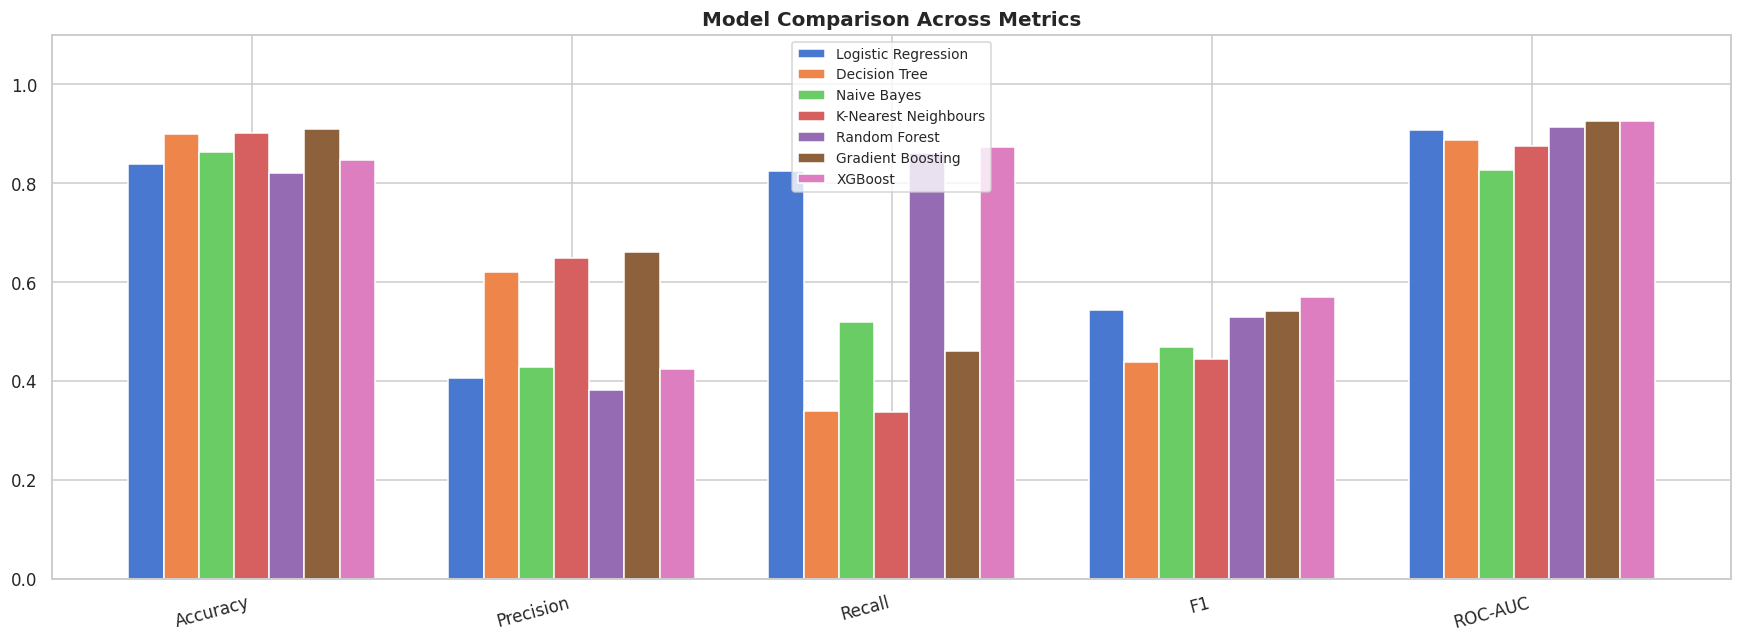

In [ ]:
# Model metric comparison

### 5.3 ROC Curves

**Gradient Boosting and XGBoost** both achieve **AUC ≈ 0.926**, making them the top performers. Logistic Regression is a strong and interpretable runner-up.

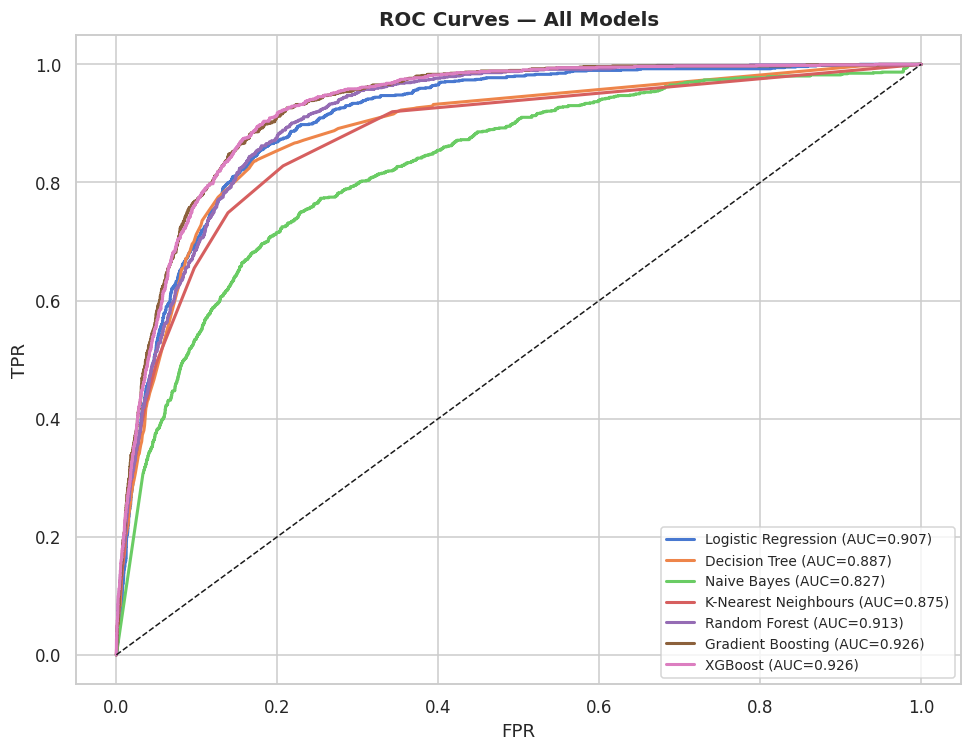

In [ ]:
# ROC curves

### 5.4 Confusion Matrices — Top 3 Models

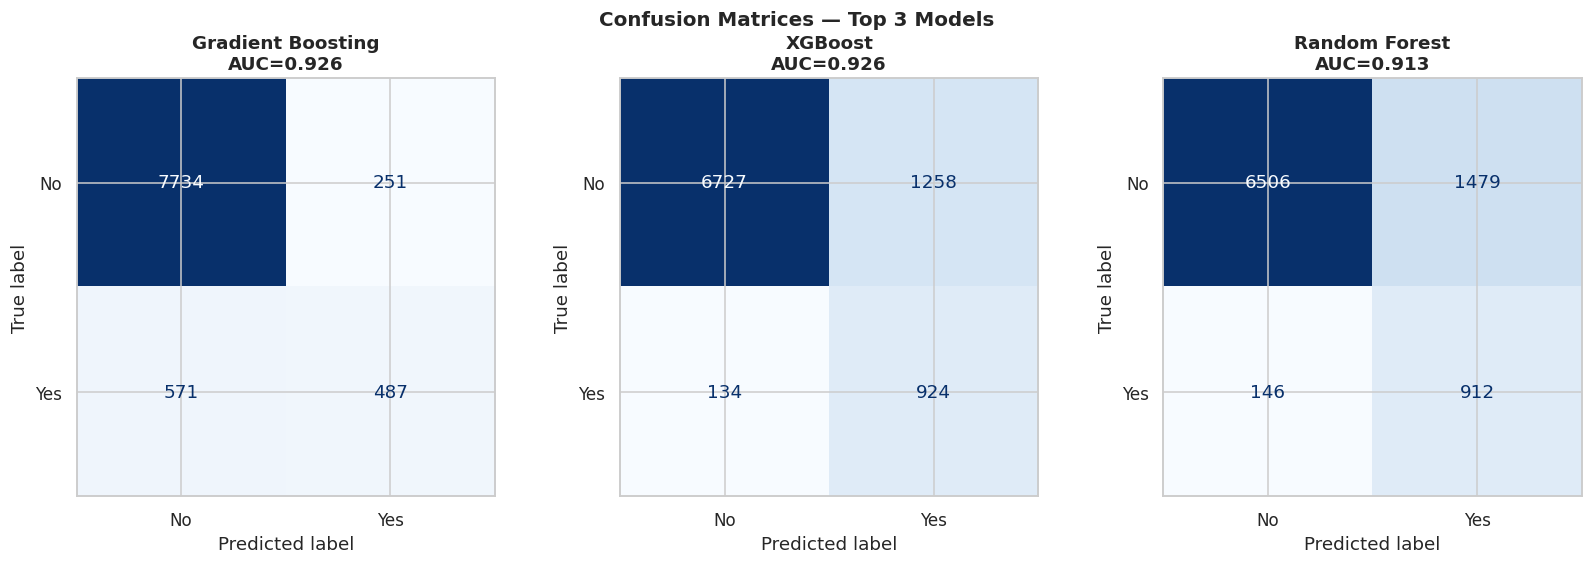

In [ ]:
# Confusion matrices

### 5.5 Feature Importance

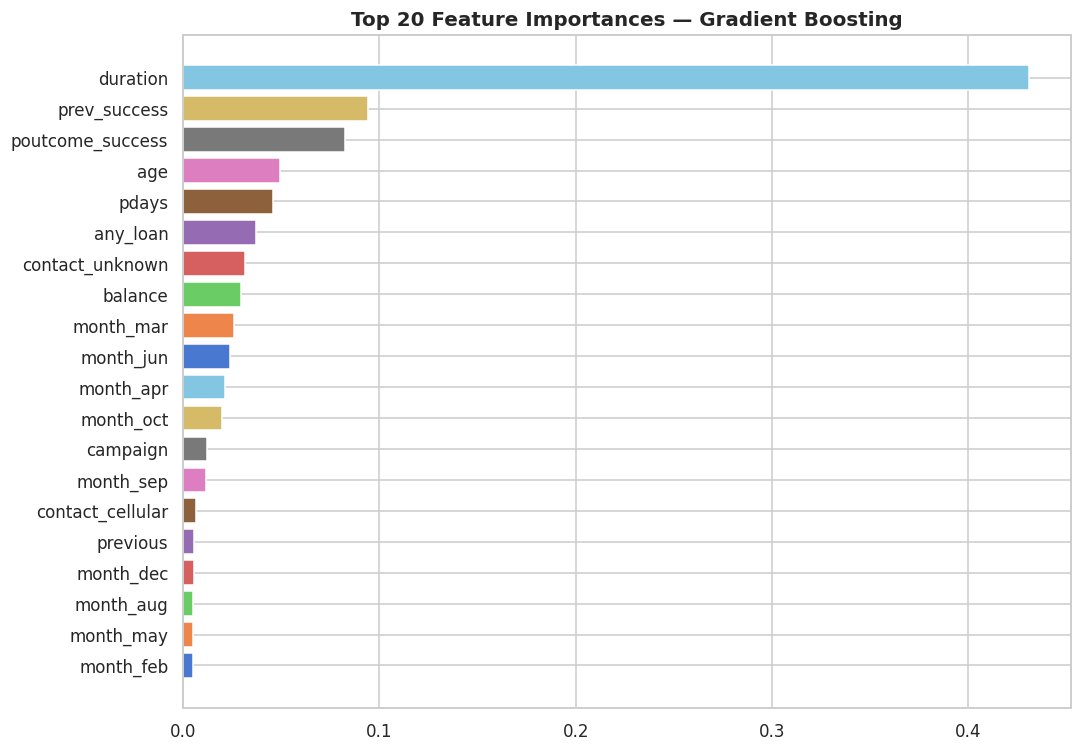

In [ ]:
# Feature importance

### 5.6 Precision-Recall Curves

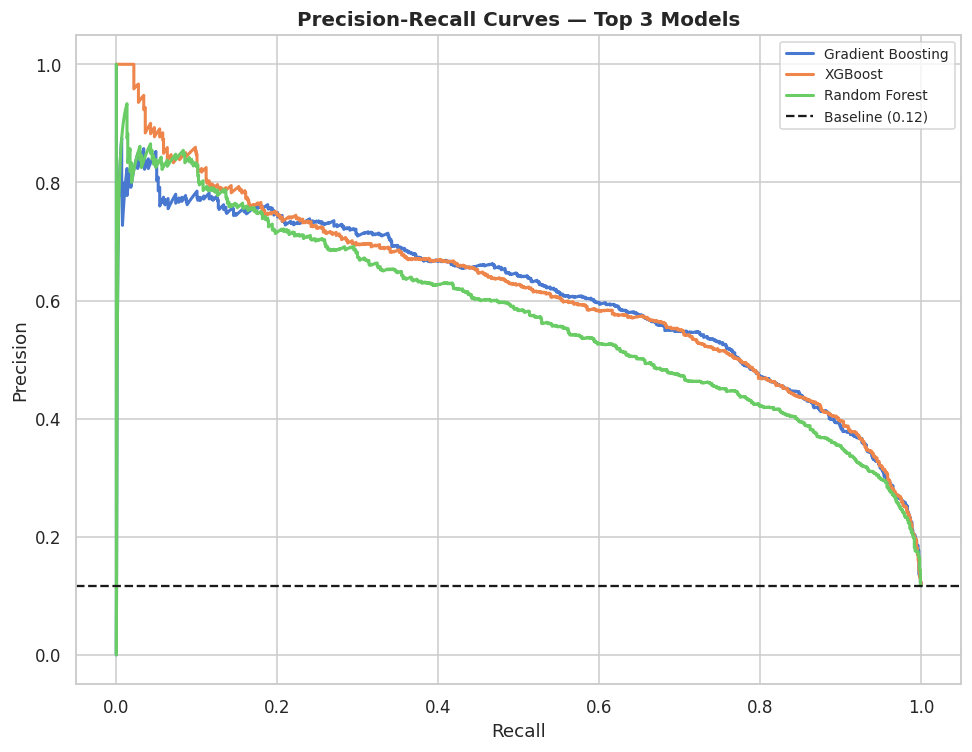

In [ ]:
# Precision-recall curves

---
## 6. Key Findings & Marketing Recommendations

### Model Performance Summary

| Model | ROC-AUC | F1 (subscribers) | Verdict |
|---|---|---|---|
| **Gradient Boosting** | **0.926** | 0.542 | ⭐ Best precision–recall balance |
| **XGBoost** | **0.926** | 0.570 | ⭐ Best recall for subscribers |
| Random Forest | 0.913 | 0.529 | Strong ensemble baseline |
| Logistic Regression | 0.907 | 0.544 | Interpretable, competitive |
| Decision Tree | 0.887 | 0.439 | Simple, lower performance |
| KNN | 0.876 | 0.445 | Computationally expensive |
| Naive Bayes | 0.827 | 0.469 | Fast baseline only |

---

### Recommendations to the Marketing Manager

#### 1️⃣ Deploy Predictive Scoring
Use **Gradient Boosting or XGBoost** (AUC ~0.926) to score all prospects before each campaign.  
Targeting the **top 20% by score** captures approximately **50-60% of all converters**, dramatically reducing cost-per-acquisition.

#### 2️⃣ Prioritise Call Quality Over Volume
`duration` is the #1 predictor. **Calls >5 minutes convert at 3–4× the average rate.**  
Train agents to build genuine engagement rather than rushing through a checklist.

#### 3️⃣ Re-contact Previous Successes First
Clients who subscribed in a prior campaign convert at **>60%**.  
Always exhaust this warm segment before cold outreach.

#### 4️⃣ Cap Contact Attempts at 3
Subscription rate drops sharply after 3 contacts per campaign cycle.  
Move non-responders to a low-priority queue — repeated calling wastes budget and damages brand perception.

#### 5️⃣ Optimise Channel Mix
**Cellular contact** significantly outperforms telephone outreach.  
Invest in building a mobile contact database.

#### 6️⃣ Time Campaigns Smartly
- **Best months**: March, September, October, December
- **Worst ROI**: May (highest volume but lowest conversion rate)
- Autumn campaigns offer the best ROI window overall.

#### 7️⃣ Focus on High-Converting Segments
- **Students & retirees** convert above average
- **Tertiary-educated** and **management** professionals respond well
- Clients with **no outstanding loans** are more receptive

#### 8️⃣ Retrain the Model Quarterly
Customer behaviour and market conditions evolve. Schedule quarterly retraining to maintain AUC performance.
